# M2S14 — Data Visualization: Latihan
## HR Employee Attrition Analysis
---

> **Petunjuk Umum**  
> 1. Jalankan seluruh sel **Data Cleaning** terlebih dahulu sebelum mengerjakan latihan  
> 2. Setiap nomor memiliki satu *Business Question* yang harus dijawab dengan visualisasi  
> 3. Tuliskan **Insight** di Markdown cell setelah setiap chart dalam format:  
>    **📊 Observasi → 🔍 Interpretasi → 📌 Rekomendasi**  
> 4. Pastikan setiap chart memiliki: judul, label sumbu (+ satuan), dan legenda jika ada lebih dari satu kategori  
> 5. Jalankan **Run All** sebelum mengumpulkan — pastikan tidak ada error


---
## A. Import Libraries & Load Data

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120


In [44]:
# Load dataset
# Pastikan file 'HR-Employee-Attrition.csv' berada di direktori yang sama dengan notebook ini

df = pd.read_csv('HR-Employee-Attrition.csv')

print(f'Shape  : {df.shape}')
print(f'Columns: {list(df.columns)}')


Shape  : (1470, 35)
Columns: ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [45]:
df.head()


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [46]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [47]:
df.describe()


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


---
## B. Data Cleaning

### Step 1 — Cek Missing Values & Duplikasi

In [48]:
# Cek missing values
print('=== Missing Values ===')
print(df.isnull().sum().sum(), 'total missing values')

# Cek duplikasi
print(f'\n=== Duplikasi ===')
print(df.duplicated().sum(), 'baris duplikat')


=== Missing Values ===
0 total missing values

=== Duplikasi ===
0 baris duplikat


### Step 2 — Drop Kolom Tidak Informatif

Tiga kolom berikut bersifat **konstan** (hanya satu nilai unik di seluruh baris):
- `EmployeeCount` → selalu **1**
- `StandardHours` → selalu **80**  
- `Over18` → selalu **"Y"**

Kolom konstan tidak memberikan informasi analitik apapun sehingga harus di-drop.


In [49]:
# Verifikasi kolom konstan
for col in ['EmployeeCount', 'StandardHours', 'Over18']:
    print(f'{col}: {df[col].unique()}')


EmployeeCount: [1]
StandardHours: [80]
Over18: <StringArray>
['Y']
Length: 1, dtype: str


In [50]:
# Drop kolom tidak informatif
cols_to_drop = ['EmployeeCount', 'StandardHours', 'Over18']
df = df.drop(columns=cols_to_drop)

print(f'Shape setelah drop: {df.shape}')  # Ekspektasi: (1470, 32)


Shape setelah drop: (1470, 32)


### Step 3 — Konversi Tipe Data

Kolom `Attrition` dan `OverTime` bertipe `object` (berisi "Yes"/"No").  
Buat kolom baru bertipe **integer** agar bisa digunakan dalam agregasi numerik (mean = rate).


In [51]:
# Buat kolom binary 0/1
df['Attrition_bin'] = df['Attrition'].map({'Yes': 1, 'No': 0})
df['OverTime_bin']  = df['OverTime'].map({'Yes': 1, 'No': 0})

# Verifikasi
print(df[['Attrition', 'Attrition_bin', 'OverTime', 'OverTime_bin']].head())


  Attrition  Attrition_bin OverTime  OverTime_bin
0       Yes              1      Yes             1
1        No              0       No             0
2       Yes              1      Yes             1
3        No              0      Yes             1
4        No              0       No             0


### Step 4 — Label Encoding Kolom Ordinal

Tambahkan label deskriptif untuk kolom **satisfaction** (skala 1–4) dan **education** (skala 1–5)  
agar label pada chart lebih mudah dibaca oleh audiens non-teknis.


In [52]:
# Mapping label satisfaction (berlaku untuk semua kolom skala 1-4)
sat_map = {1: 'Low', 2: 'Medium', 3: 'High', 4: 'Very High'}

df['JobSatisfaction_label']  = df['JobSatisfaction'].map(sat_map)
df['WorkLifeBalance_label']  = df['WorkLifeBalance'].map(sat_map)
df['EnvSatisfaction_label']  = df['EnvironmentSatisfaction'].map(sat_map)
df['RelSatisfaction_label']  = df['RelationshipSatisfaction'].map(sat_map)

# Mapping label education
edu_map = {1: 'Below College', 2: 'College', 3: 'Bachelor', 4: 'Master', 5: 'Doctor'}
df['Education_label'] = df['Education'].map(edu_map)

print('Label columns added:', ['JobSatisfaction_label', 'WorkLifeBalance_label',
                                'EnvSatisfaction_label', 'RelSatisfaction_label',
                                'Education_label'])


Label columns added: ['JobSatisfaction_label', 'WorkLifeBalance_label', 'EnvSatisfaction_label', 'RelSatisfaction_label', 'Education_label']


### Step 5 — Verifikasi Final

In [53]:
print(f'Shape final      : {df.shape}')
print(f'Attrition dist.  : {df["Attrition"].value_counts().to_dict()}')
print(f'Attrition rate   : {df["Attrition_bin"].mean()*100:.1f}% karyawan keluar')
print(f'OverTime rate    : {df["OverTime_bin"].mean()*100:.1f}% karyawan lembur')
print(f'\nKolom akhir ({df.shape[1]}):')
print(list(df.columns))


Shape final      : (1470, 39)
Attrition dist.  : {'No': 1233, 'Yes': 237}
Attrition rate   : 16.1% karyawan keluar
OverTime rate    : 28.3% karyawan lembur

Kolom akhir (39):
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'Attrition_bin', 'OverTime_bin', 'JobSatisfaction_label', 'WorkLifeBalance_label', 'EnvSatisfaction_label', 'RelSatisfaction_label', 'Education_label']


---
## C. Latihan Visualisasi

---
### No. 1 — Distribusi Usia Karyawan

**Business Question:**  
*Bagaimana distribusi usia karyawan di perusahaan ini? Apakah ada perbedaan pola usia antara karyawan yang resign dan yang tidak?*

**Kolom:** `Age`, `Attrition`


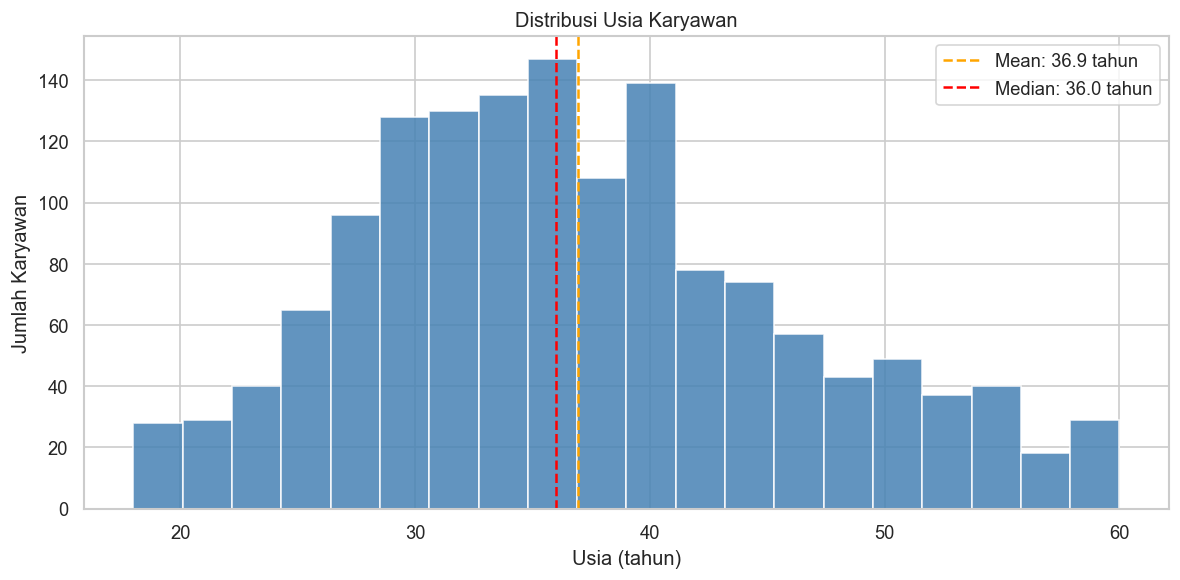

In [54]:
# ── Blok 1: Distribusi usia keseluruhan ──────────────────────────────────────

plt.figure(figsize=(10,5))

plt.hist(df['Age'], bins=20, color='steelblue', edgecolor='white', alpha=0.85)
plt.axvline(df['Age'].mean(),   color='orange', linestyle='--', linewidth=1.5,
           label=f"Mean: {df['Age'].mean():.1f} tahun")
plt.axvline(df['Age'].median(), color='red',    linestyle='--', linewidth=1.5,
           label=f"Median: {df['Age'].median():.1f} tahun")

plt.title('Distribusi Usia Karyawan')
plt.xlabel('Usia (tahun)')
plt.ylabel('Jumlah Karyawan')
plt.legend()

plt.tight_layout()
plt.show()


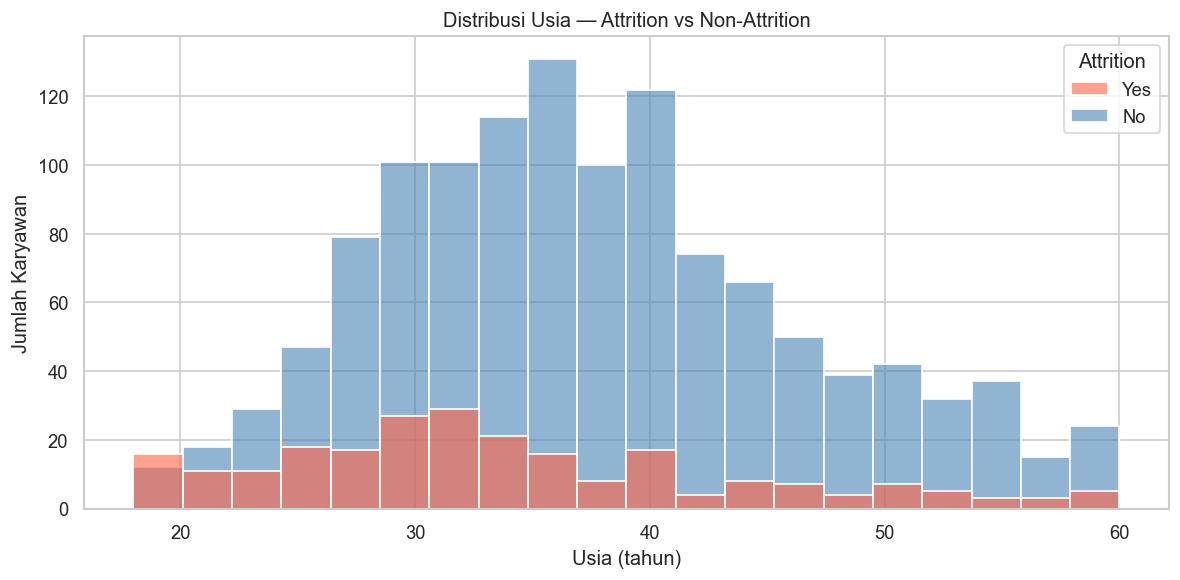

In [55]:
# ── Blok 2: Perbandingan usia per Attrition group ────────────────────────────

plt.figure(figsize=(10,5))

# TODO: Tampilkan distribusi usia untuk Attrition=Yes dan Attrition=No
# Gunakan sns.histplot() dengan parameter:
#   - hue='Attrition'
#   - bins=20
#   - alpha=0.6
#   - palette={'No': 'steelblue', 'Yes': 'tomato'}
# agar kedua distribusi terlihat overlap

sns.histplot(data=df, x='Age', hue='Attrition', bins=20,
             alpha=0.6, palette={'No': 'steelblue', 'Yes': 'tomato'})

plt.title('Distribusi Usia — Attrition vs Non-Attrition')
plt.xlabel('Usia (tahun)')
plt.ylabel('Jumlah Karyawan')

plt.tight_layout()
plt.show()


#### 💡 Insight No. 1

| | |
|---|---|
| 📊 **Observasi** | The distribution of age in this company hovers between the late 20s to 40 years old with a median of 36 and a mean of 36.9. Moreover, the younger employees (Aged 25-35) tends to have more attrition rate compared to the more senior employees (Attrition = yes). 
| 🔍 **Interpretasi** | The younger employees, most likely with lower experience tends to quit their jobs. This has multiple factors such as better career opportunities, lack of loyalty compared to the older generations, and below satisfactory pay.|
| 📌 **Rekomendasi** | *As an HR it is recommended to make a program to guide younger employees with mentorship and guidance. Moreover, a more competitive pay and a clear career path will deter employees from leaving for better career opportunities.* |


---
### No. 2 — Gaji Karyawan Lembur vs Tidak Lembur

**Business Question:**  
*Apakah karyawan yang lembur cenderung mendapatkan gaji lebih rendah? Apakah pola ini berbeda antara karyawan yang resign dan yang tidak?*
 
**Kolom:** `MonthlyIncome`, `OverTime`, `Attrition`


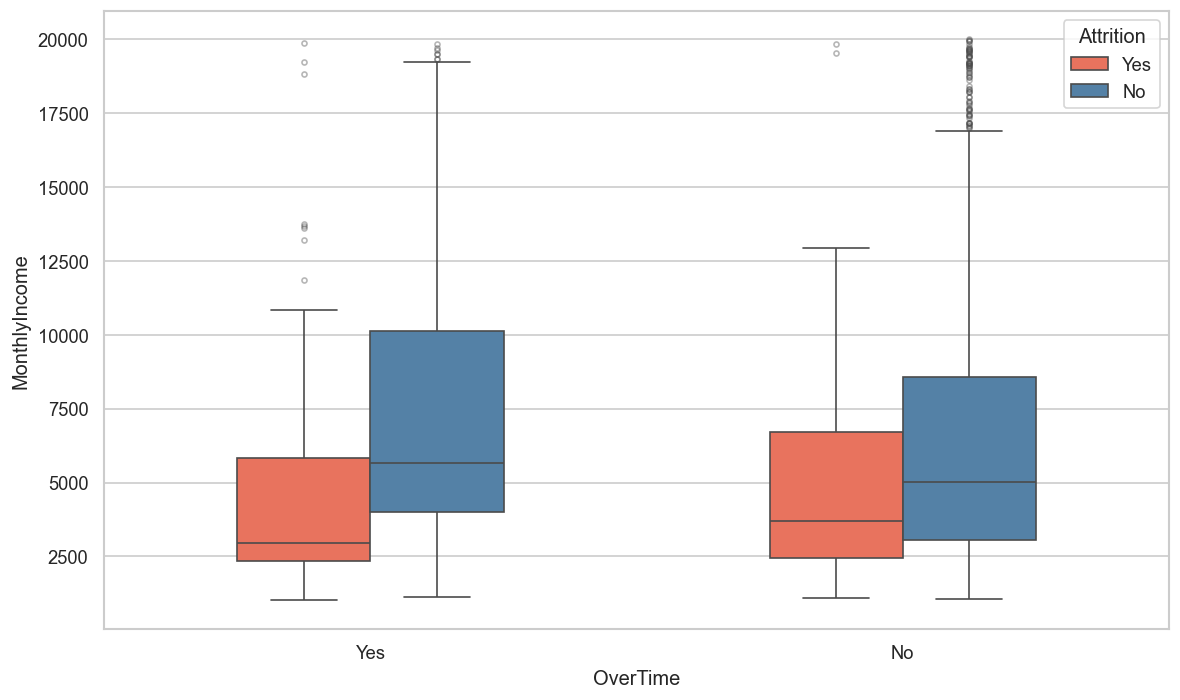

In [56]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df,
    x='OverTime',
    y='MonthlyIncome',
    hue='Attrition',
    palette={'No': 'steelblue', 'Yes': 'tomato'},
    width=0.5,
    flierprops=dict(marker='o', markersize=3, alpha=0.4)
)

# TODO: Tambahkan judul chart yang deskriptif
# TODO: Tambahkan label sumbu X dan Y (sertakan satuan pada sumbu Y)
# TODO: Format angka sumbu Y dengan pemisah ribuan
#       Hint: ax.yaxis.set_major_formatter(
#                 mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()


#### 💡 Insight No. 2

| | |
|---|---|
| 📊 **Observasi** | Employees with overtime and ended up resigning have lower pay compared to their counterparts which stayed in the company. On the other hand, the same trend also follows for employees that doesn't work overtime with employees that resigned having lower pay compared to their counterparts who stayed.
| 🔍 **Interpretasi** | *From those observations, the lack of sufficient pay may be a factor of employee attrition. Not to mention the lack of extra pay combined with more workload which is a main driving factor to attrition.* |
| 📌 **Rekomendasi** | *Based on our interpretation, an improvement to work-life balance such as having less workload during overtime combined with more pay to compensate for the extra work hours.* |


---
### No. 3 — Tren Rata-rata Gaji berdasarkan Lama Bekerja

**Business Question:**  
*Bagaimana tren rata-rata gaji seiring bertambahnya lama bekerja di perusahaan? Apakah tren ini berbeda antara karyawan yang resign dan yang tidak?*

**Kolom:** `YearsAtCompany`, `MonthlyIncome`, `Attrition`


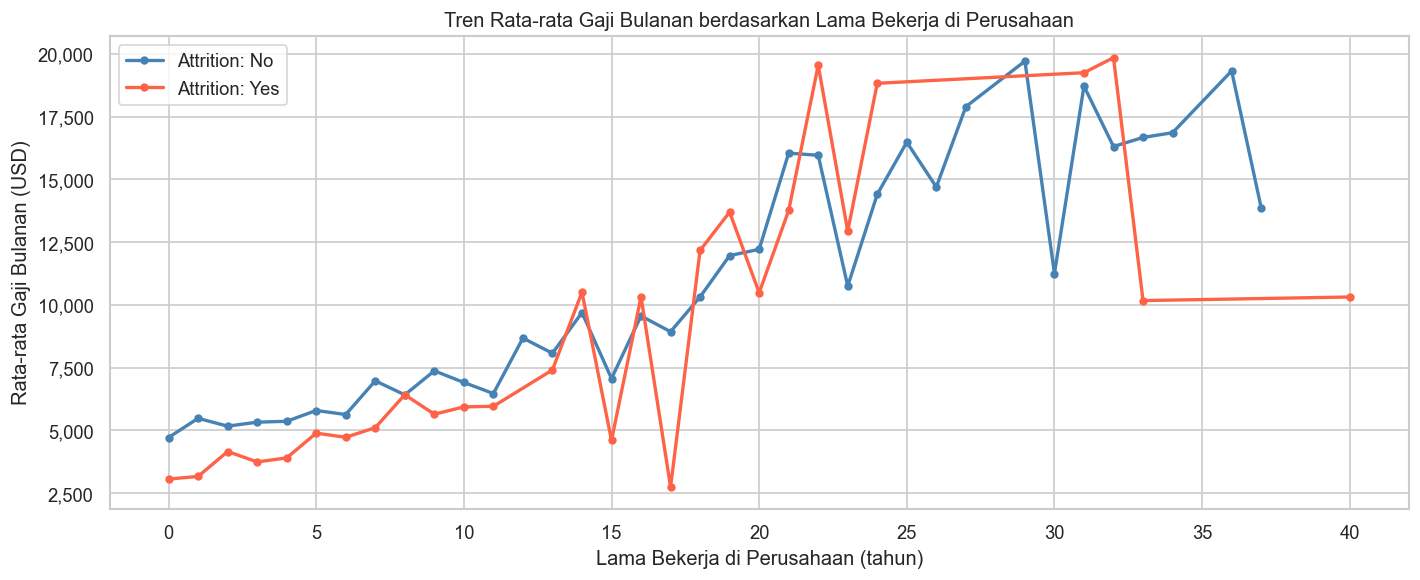

In [57]:
# Aggregasi rata-rata gaji per YearsAtCompany per Attrition group
trend = (
    df.groupby(['YearsAtCompany', 'Attrition'])['MonthlyIncome']
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 5))

for group, color in [('No', 'steelblue'), ('Yes', 'tomato')]:
    subset = trend[trend['Attrition'] == group]
    plt.plot(subset['YearsAtCompany'], subset['MonthlyIncome'],
            marker='o', markersize=4, color=color,
            linewidth=2, label=f'Attrition: {group}')

# TODO: Tambahkan judul chart yang deskriptif
# TODO: Tambahkan label sumbu X dan Y (sertakan satuan)
# TODO: Tambahkan legend
# TODO: Format angka sumbu Y dengan pemisah ribuan

plt.title('Tren Rata-rata Gaji Bulanan berdasarkan Lama Bekerja di Perusahaan')
plt.xlabel('Lama Bekerja di Perusahaan (tahun)')
plt.ylabel('Rata-rata Gaji Bulanan (USD)')
plt.legend()
plt.gca().yaxis.set_major_formatter(
mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()


#### 💡 Insight No. 3

| | |
|---|---|
| 📊 **Observasi** | *Based on the visualization above, the monthly income increases as they stayed longer in the company. However, trend shows that the average income of employee that ended up resigning(Tomato red) is lower compared to the income of those who stayed (Steel blue). Furthermore, there are also data that shows that the lack of salary increase contributed to a high atrition rate, especially for those who have worked for 20-30 years.* |
| 🔍 **Interpretasi** | *Employees that have resigned could be a factor of not having their salary meeting their expectation, hence the higher attrition rate compared to employees that has higher salary. Moreover, the increase in income may not be suffecient to their expectation hence the higher attrition rate on the early years. On the other hand, employees that have higher salary tend to be more loyal. Age is also a factor as the longer they work, the lesser the chance of attrition due to having satisfactory income the longer they stay in the company.* |
| 📌 **Rekomendasi** | *As an HR it's best to review on how to motivate younger employees with salary incentives, this will lower attrition rate and promote growth and loyalty within the company.* |


---
### No. 4 — Hubungan Usia dan Gaji Bulanan Karyawan

**Business Question:**  
*Apakah ada hubungan antara usia dan gaji bulanan karyawan? Di area usia dan gaji berapa karyawan yang resign paling banyak terkonsentrasi?*

**Kolom:** `Age`, `MonthlyIncome`, `Attrition`


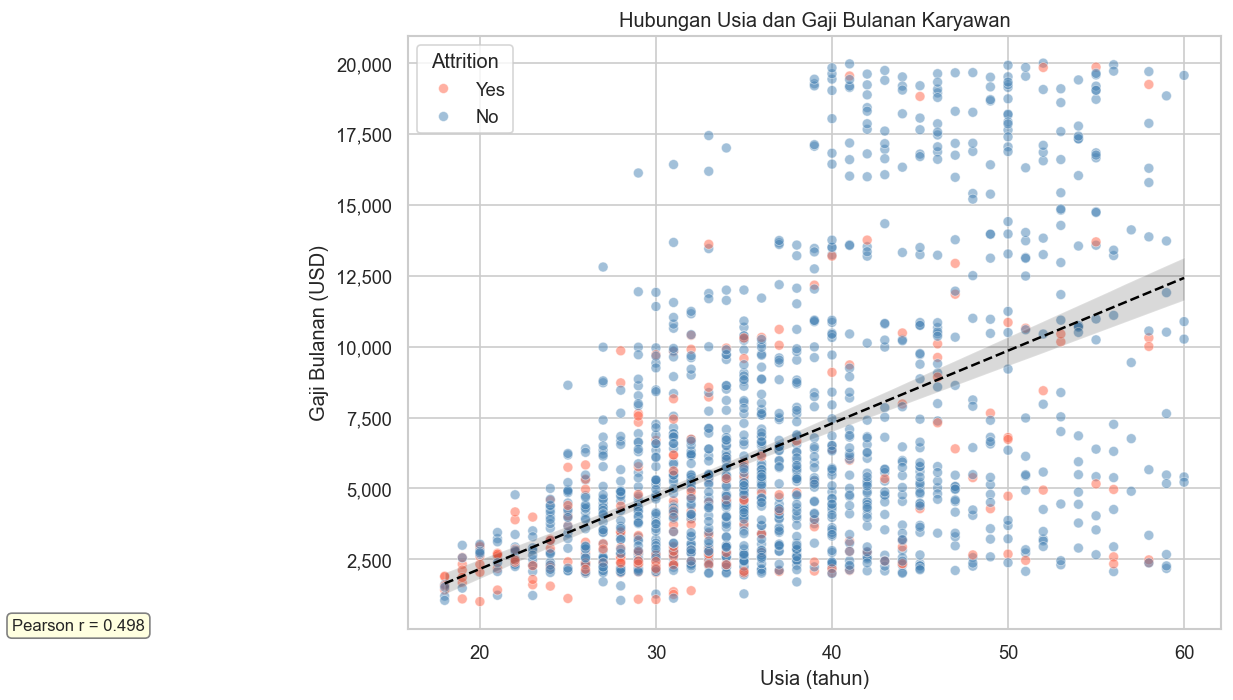

In [58]:

plt.figure(figsize=(11,6))
# Scatter plot dengan hue Attrition
sns.scatterplot(
    data=df,
    x='Age',
    y='MonthlyIncome',
    hue='Attrition',
    palette={'No': 'steelblue', 'Yes': 'tomato'},
    alpha=0.5,
    s=35,
)

# Regression line (overall trend)
sns.regplot(
    data=df, x='Age', y='MonthlyIncome',
    scatter=False, color='black',
    line_kws={'linewidth': 1.5, 'linestyle': '--'},
)

# Pearson correlation annotation
r = df['Age'].corr(df['MonthlyIncome'])
plt.text(0.97, 0.05, f'Pearson r = {r:.3f}',ha='right', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='gray'))

# TODO: Tambahkan judul chart yang deskriptif
# TODO: Tambahkan label sumbu X dan Y (sertakan satuan)
# TODO: Format angka sumbu Y dengan pemisah ribuan
plt.title('Hubungan Usia dan Gaji Bulanan Karyawan')
plt.xlabel('Usia (tahun)')
plt.ylabel('Gaji Bulanan (USD)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()


#### 💡 Insight No. 4

| | |
|---|---|
| 📊 **Observasi** | *Based on the data above, younger employees with lower income tends to quit more (Especially below 5000$ a month). However more senior employees tends to stay loyal with attrition rate seeing a sharp decline on employees above 30 years old. The consistent increase in salary is also a factor as attrition rate becoming less and less prevalent with the older employees.* |
| 🔍 **Interpretasi** | *Younger employees with low salary are at a bigger risk quitting the company. The entry level salary isn't satisfactory as most attrition occurs for at entry to junior level. However senior employees get to enjoy a satisfactory increase in pay, hence the loyalty.* |
| 📌 **Rekomendasi** | *More salary incentives and more path for promotion especially for entry level position that offers below 5000$ monthly salary.* |


---
### No. 5 — Jumlah Karyawan per Department

**Business Question:**  
*Department mana yang memiliki jumlah karyawan terbanyak?*

**Kolom:** `Department`

**Petunjuk:**
- Hitung jumlah karyawan per `Department` menggunakan `value_counts()`
- Urutkan bar dari nilai terbesar ke terkecil
- Tambahkan anotasi jumlah di atas tiap bar
- Beri warna berbeda (highlight) untuk bar dengan nilai tertinggi


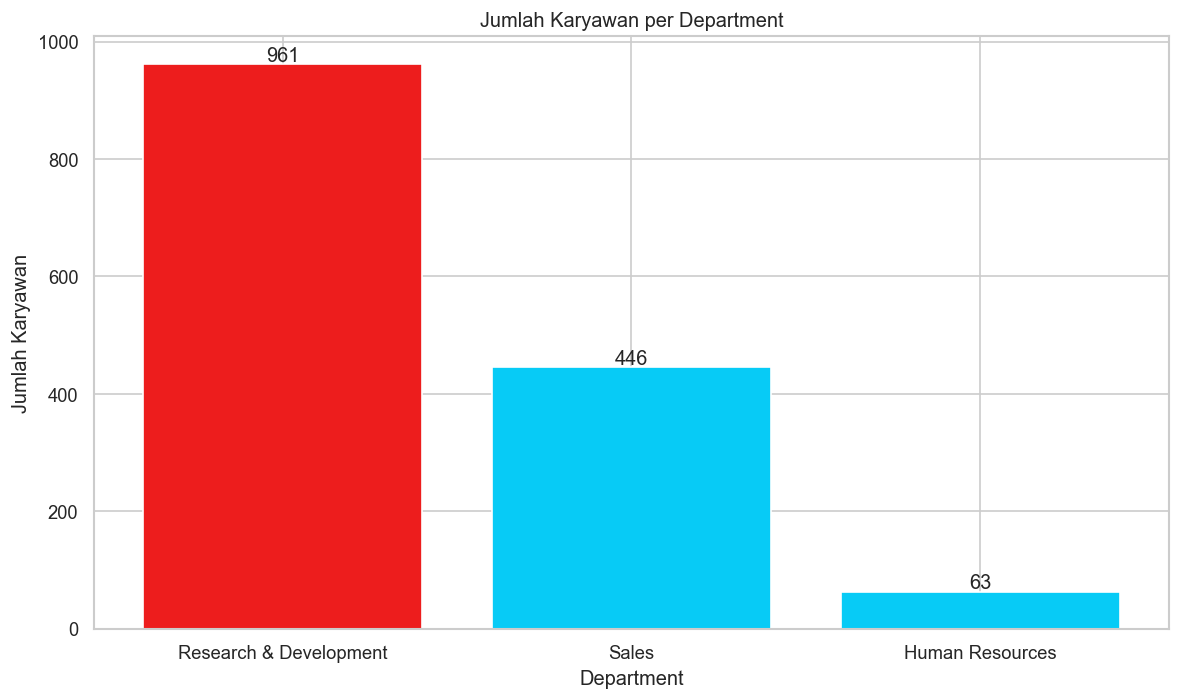

In [59]:
# No. 5 — Kerjakan di sini

dept_counts = df["Department"].value_counts().sort_values(ascending=False)

colors = ["#ed1d1d"] + ["#07cbf6"] * (len(dept_counts) - 1)
plt.figure(figsize=(10,6))
bars = plt.bar(dept_counts.index, dept_counts.values, color=colors)

# Tambahkan anotasi jumlah di atas bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 5,
        f'{int(height)}',
        ha='center'
    )

plt.title('Jumlah Karyawan per Department')
plt.xlabel('Department')
plt.ylabel('Jumlah Karyawan')
plt.tight_layout()
plt.show()

#### 💡 Insight No. 5

| | |
|---|---|
| 📊 **Observasi** | *R&D has the highest employee count with 961 followed by Sales Department at 446 employee with HR having the lowest amount at just 63 emlpoyee.* |
| 🔍 **Interpretasi** | *With the majority of employee mostly working in R&D, it's probable that the company is tech-oriented with Sales Department making up half the R&D team.* |
| 📌 **Rekomendasi** | *Since most tech companies have a ratio between 1:50 to 1:150 of HR professionals per employees, it's best to cut down on H&R number to save cost and maximize profit.A 1:23 ratio is a bit too much, especially for a large company (>500 employees).* |


---
### No. 6 — Proporsi Tingkat Pendidikan Karyawan

**Business Question:**  
*Bagaimana proporsi tingkat pendidikan karyawan di perusahaan ini?*

**Kolom:** `Education_label`

**Petunjuk:**
- Gunakan kolom `Education_label` hasil mapping dari Step 4 cleaning
- Urutkan dengan `reindex()`: Below College → College → Bachelor → Master → Doctor
- Tampilkan persentase di setiap irisan dengan `autopct='%1.1f%%'`
- Tambahkan `edgecolor='white'` pada `wedgeprops` agar irisan terpisah jelas


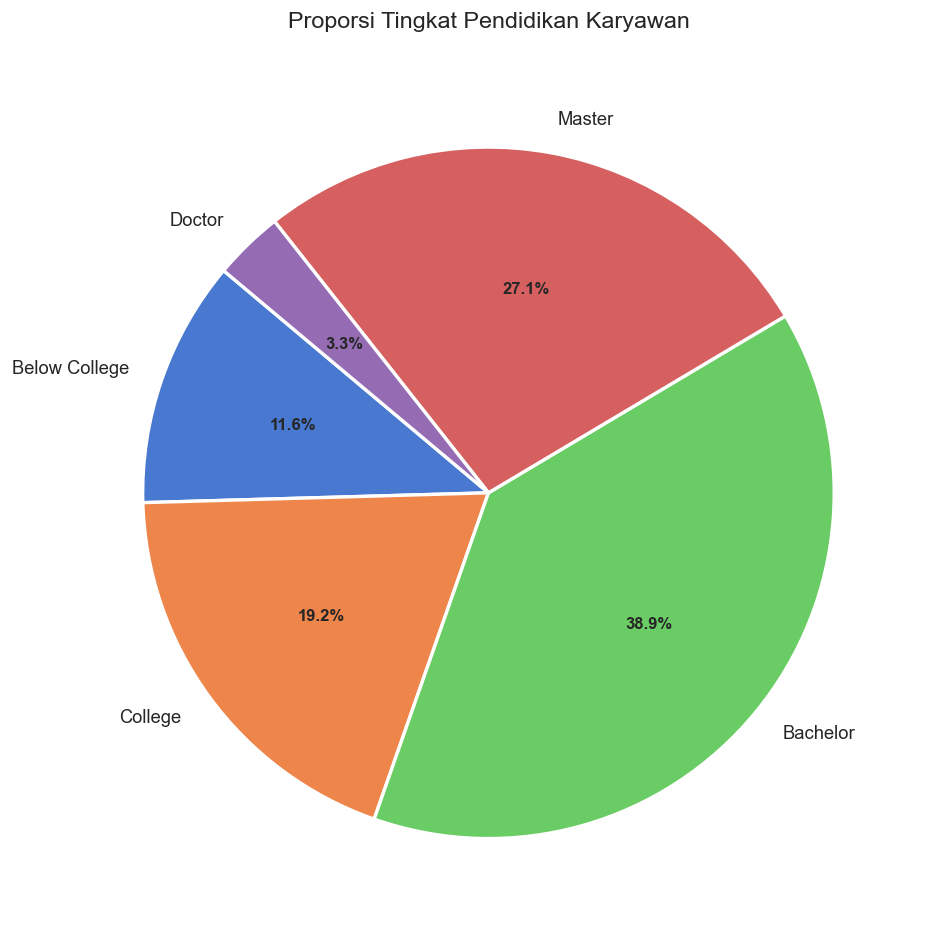

In [60]:
# No. 6 — Kerjakan di sini
edu_order = ["Below College", "College", "Bachelor", "Master", "Doctor"]
edu_counts = df['Education_label'].value_counts().reindex(edu_order)

colors_edu = sns.color_palette('muted', len(edu_order))

fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    edu_counts.values,
    labels=edu_counts.index,
    autopct='%1.1f%%',
    colors=colors_edu,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    startangle=140
)

for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')

ax.set_title('Proporsi Tingkat Pendidikan Karyawan', fontsize=14, pad=20)

plt.tight_layout()
plt.show()

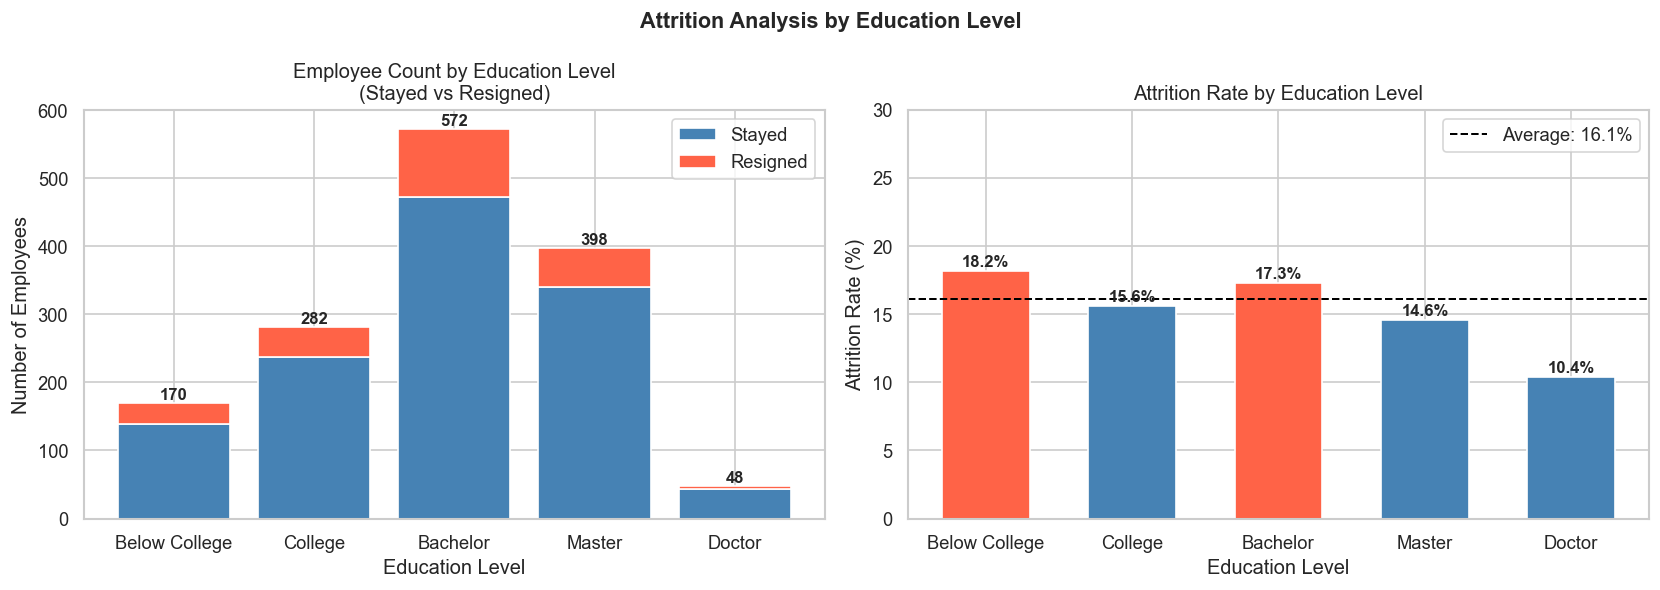

In [61]:
# Before drawing the stacked bar + attrition rate chart we need to
# build edu_summary: a small table with counts (stayed, resigned, total)
# and attrition_rate for each education level.
#
# Step-by-step:
#   1. groupby Education_label + Attrition → count rows
#   2. unstack() turns Attrition (Yes/No) into columns
#   3. reindex to keep levels in the right order
#   4. compute attrition_rate = resigned / total * 100

edu_order = ['Below College', 'College', 'Bachelor', 'Master', 'Doctor']

edu_raw = (
    df.groupby(['Education_label', 'Attrition'])
    .size()
    .unstack(fill_value=0)
    .reindex(edu_order)
)

edu_summary = {
    'stayed':         edu_raw['No'].values,
    'resigned':       edu_raw['Yes'].values,
    'total':          (edu_raw['No'] + edu_raw['Yes']).values,
    'attrition_rate': (edu_raw['Yes'] / (edu_raw['No'] + edu_raw['Yes']) * 100)
                      .round(1).values,
}

# ── Plot: Stacked bar (left) + Attrition rate (right) ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LEFT: stacked bar showing absolute counts of Stayed vs Resigned
axes[0].bar(edu_order, edu_summary['stayed'],  color='steelblue', label='Stayed',  edgecolor='white')
axes[0].bar(edu_order, edu_summary['resigned'], color='tomato',    label='Resigned', edgecolor='white',
            bottom=edu_summary['stayed'])   # 'bottom' stacks on top of the Stayed bars

# Annotate total count above each bar
for i, (stayed, resigned, total) in enumerate(zip(
        edu_summary['stayed'], edu_summary['resigned'], edu_summary['total'])):
    axes[0].text(i, total + 5, str(total), ha='center', fontsize=10, fontweight='bold')

axes[0].set_title('Employee Count by Education Level\n(Stayed vs Resigned)')
axes[0].set_xlabel('Education Level')
axes[0].set_ylabel('Number of Employees')
axes[0].legend()

# RIGHT: attrition rate per education level
# Bars above the company average are highlighted tomato, others steelblue
avg_rate = df['Attrition_bin'].mean() * 100
bar_colors = ['tomato' if v > avg_rate else 'steelblue' for v in edu_summary['attrition_rate']]
bars = axes[1].bar(edu_order, edu_summary['attrition_rate'], color=bar_colors,
                   edgecolor='white', width=0.6)

# Annotate the % above each bar
for bar, val in zip(bars, edu_summary['attrition_rate']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val}%', ha='center', fontweight='bold', fontsize=10)

# Dashed horizontal line = company-wide average attrition rate
axes[1].axhline(avg_rate, color='black', linestyle='--',
                linewidth=1.2, label=f'Average: {avg_rate:.1f}%')
axes[1].set_title('Attrition Rate by Education Level')
axes[1].set_xlabel('Education Level')
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].set_ylim(0, 30)
axes[1].legend()

plt.suptitle('Attrition Analysis by Education Level', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


#### 💡 Insight No. 6

| | |
|---|---|
| 📊 **Observasi** | *The majority of employees have higher education with 38.9% having bachelor's degree followed by 27.1% having master's degree, 19.2 having college degree, 11.6% didn't pursue higher education, and finally 3.3% having a doctorate degree. We can sum it up to having 88.6% of people having a higher education background while only 11.4% not having any.* |
| 🔍 **Interpretasi** | *This company mostly consisted of people having higher education hence why the high turnover rate at a younger age. A high education background tends to have a higher expectation of salary, hence why there's a large turnover rate for the younger employees.* |
| 📌 **Rekomendasi** | *Just like before, a mentorship system and a more competitive entry-level - junior salary alongside more company benefits will help reduce attrition rate amoung younger employees.* |


---
### No. 7 — Apakah karyawan yang resign memiliki distribusi gaji yang berbeda?

**Business Question:**  
*Apakah karyawan yang resign memiliki distribusi gaji yang berbeda?*
 
**Kolom:** `MonthlyIncome`, `Attrition`


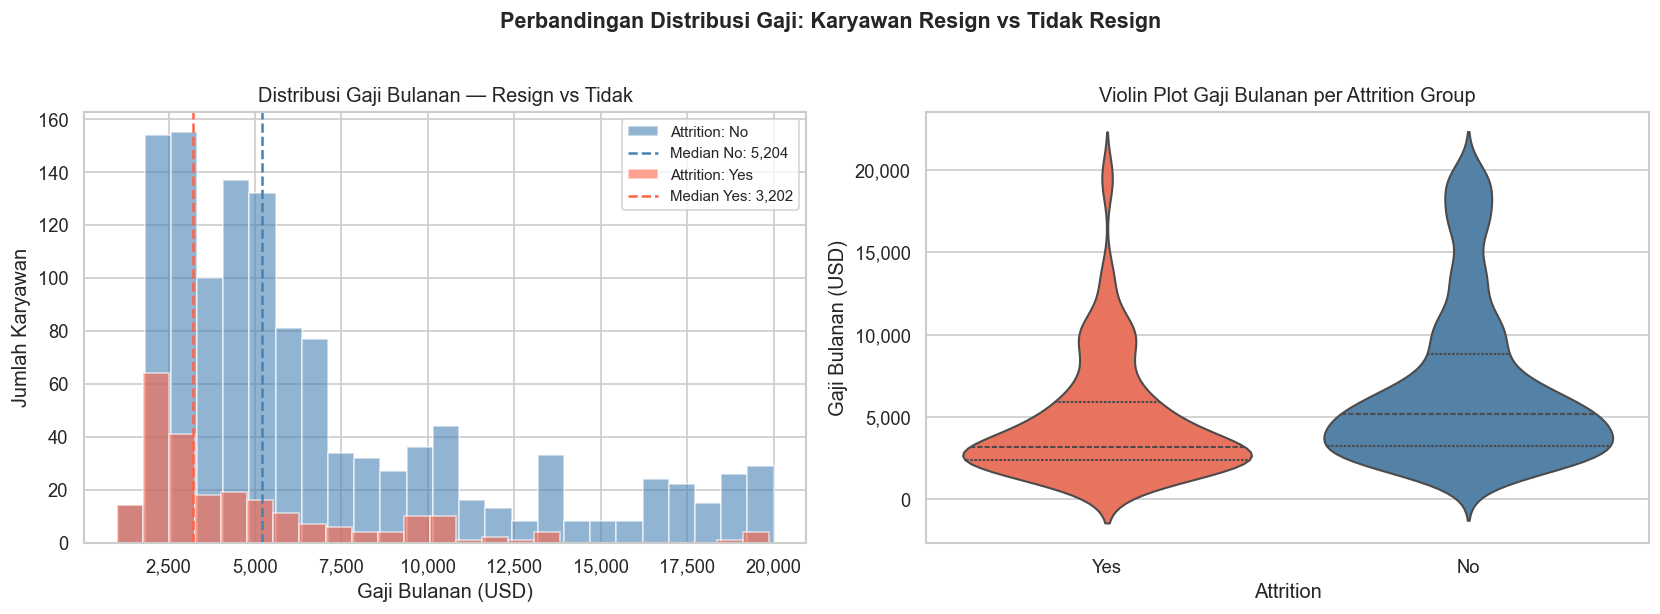

In [62]:
# No. 7 — Kerjakan di sini
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot kiri: Histogram overlay
for group, color in [('No', 'steelblue'), ('Yes', 'tomato')]:
    subset = df[df['Attrition'] == group]['MonthlyIncome']
    axes[0].hist(subset, bins=25, alpha=0.6, color=color, edgecolor='white', label=f'Attrition: {group}')
    axes[0].axvline(subset.median(), color=color, linestyle='--', linewidth=1.5,
                    label=f'Median {group}: {int(subset.median()):,}')

axes[0].set_title('Distribusi Gaji Bulanan — Resign vs Tidak')
axes[0].set_xlabel('Gaji Bulanan (USD)')
axes[0].set_ylabel('Jumlah Karyawan')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].legend(fontsize=9)

# Plot kanan: Violin plot
sns.violinplot(data=df, x='Attrition', y='MonthlyIncome',
               palette={'No': 'steelblue', 'Yes': 'tomato'},
               inner='quartile', ax=axes[1])
axes[1].set_title('Violin Plot Gaji Bulanan per Attrition Group')
axes[1].set_xlabel('Attrition')
axes[1].set_ylabel('Gaji Bulanan (USD)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Perbandingan Distribusi Gaji: Karyawan Resign vs Tidak Resign',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#### 💡 Insight No. 7

| | |
|---|---|
| 📊 **Observasi** | *Most employees who resigned tend to have low salary in general (Around 3000 USD mark) compared to those who are well compensated (5000 USD). The distribution of attrition is also right-skewed as evidenced by the decreasing number of attrition with higher salary.* |
| 🔍 **Interpretasi** | *Low salary is the biggest contributing factor to attrition. Most employees feel disatisfied with their compensation and tend to look for further career opportunities from other companies. This is also especially true for highly educated employees who also expects higher compensation for their specialized education/skill.* |
| 📌 **Rekomendasi** | *Research the market for changes in salary and expectations of entry-junior level positions, evaluate employees based on their performance and education to prevent talent drain.* |


---
### No. 8 — Bagaimana perbandingan WorkLifeBalance antar Department?

**Business Question:**  
*Bagaimana perbandingan WorkLifeBalance antar Department?*
 
**Kolom:** `WorkLifeBalance`, `Department`, `Attrition`


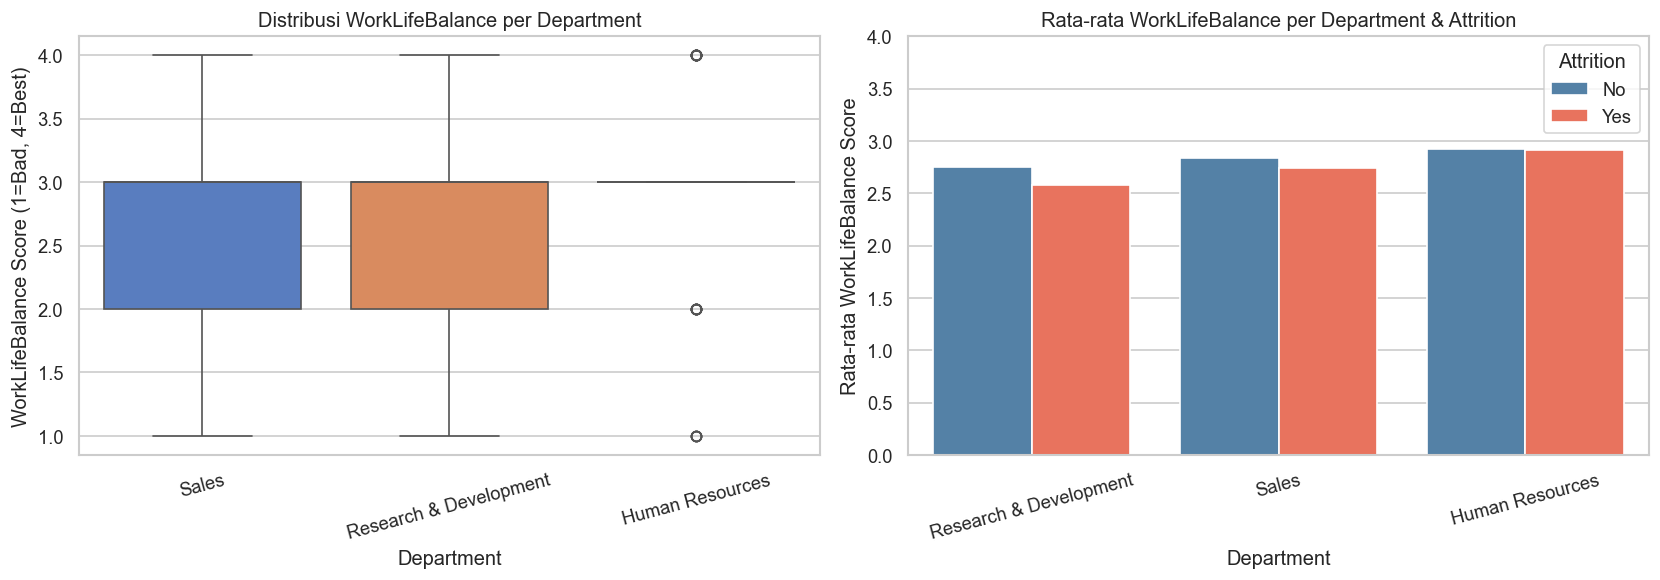

In [63]:
# No. 8 — Kerjakan di sini
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot kiri: Boxplot WLB per dept
sns.boxplot(data=df, x='Department', y='WorkLifeBalance',
            palette='muted', ax=axes[0])
axes[0].set_title('Distribusi WorkLifeBalance per Department')
axes[0].set_xlabel('Department')
axes[0].set_ylabel('WorkLifeBalance Score (1=Bad, 4=Best)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15)

# Plot kanan: Grouped bar - avg WLB by dept & attrition
wlb_dept = df.groupby(['Department', 'Attrition'])['WorkLifeBalance'].mean().reset_index()
dept_order = df.groupby('Department')['WorkLifeBalance'].mean().sort_values().index.tolist()
sns.barplot(data=wlb_dept, x='Department', y='WorkLifeBalance', hue='Attrition',
            palette={'No': 'steelblue', 'Yes': 'tomato'},
            order=dept_order, ax=axes[1])
axes[1].set_title('Rata-rata WorkLifeBalance per Department & Attrition')
axes[1].set_xlabel('Department')
axes[1].set_ylabel('Rata-rata WorkLifeBalance Score')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15)
axes[1].set_ylim(0, 4)

plt.tight_layout()
plt.show()

#### 💡 Insight No. 8

| | |
|---|---|
| 📊 **Observasi** | *(All three departments seem to have similiar work-life balance scores. HR seems to be higher on average compared to sales and especially R&D which has the lowest work-life balance. The data also shows that employees who resigned tend to have a trend of having lower work-life balance scores. )* |
| 🔍 **Interpretasi** | *The workload between all three departments are mostly similiar but there's one undeniable fact. Most employees that resigned tend to be unhappy regarding their workload, which contributed to the attrition rate.* |
| 📌 **Rekomendasi** | *Instead of surveying the whole department, it would be better to do it in smaller population like teams. This will give more insight to how better to optimize the workflow of the company (Things such as increasing automation can drastically reduce workload for example).* |


---
### No. 9 — JobRole mana yang memiliki tingkat attrition tertinggi?

**Business Question:**  
*JobRole mana yang memiliki tingkat attrition tertinggi?*
 
**Kolom:** `JobRole`, `Attrition_bin`


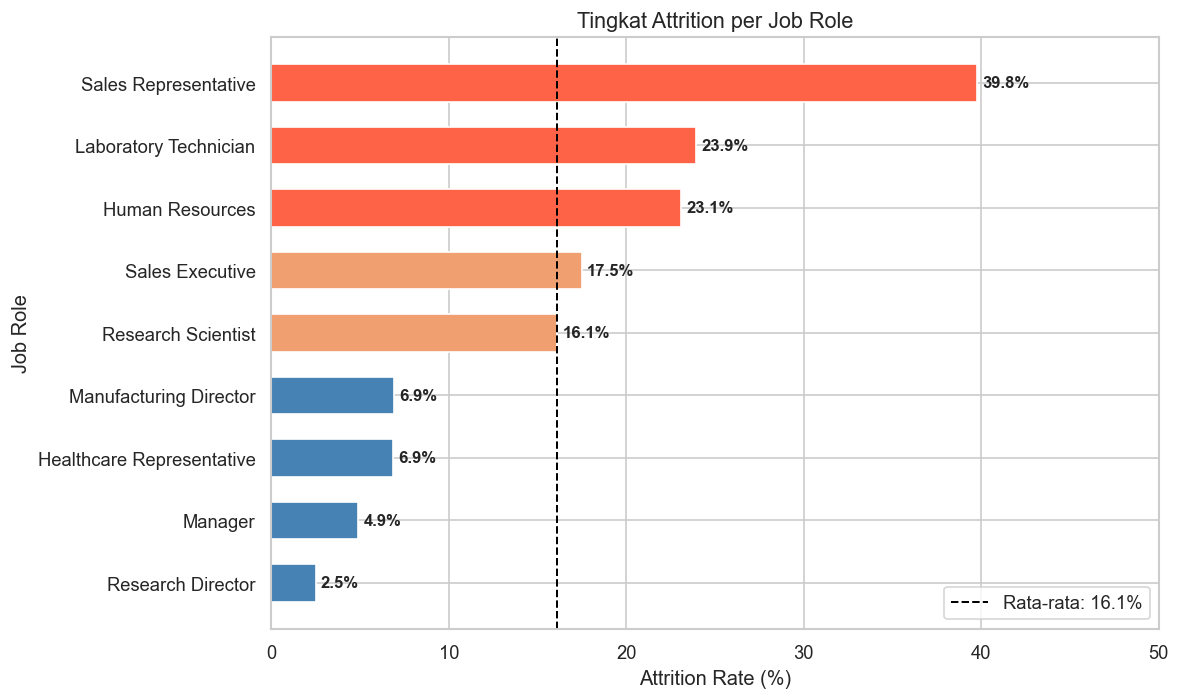

In [77]:
attrition_by_role = (
    df.groupby('JobRole')['Attrition_bin']
    .mean()
    .sort_values(ascending=True)
    .reset_index()
)
attrition_by_role['Attrition_pct'] = attrition_by_role['Attrition_bin'] * 100

colors = ['tomato' if v >= 20 else ('steelblue' if v < 10 else '#f0a070')
          for v in attrition_by_role['Attrition_pct']]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(attrition_by_role['JobRole'], attrition_by_role['Attrition_pct'],
               color=colors, edgecolor='white', height=0.6)

for bar, val in zip(bars, attrition_by_role['Attrition_pct']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')

ax.axvline(df['Attrition_bin'].mean()*100, color='black', linestyle='--',
           linewidth=1.2, label=f"Rata-rata: {df['Attrition_bin'].mean()*100:.1f}%")
ax.set_title('Tingkat Attrition per Job Role', fontsize=13)
ax.set_xlabel('Attrition Rate (%)')
ax.set_ylabel('Job Role')
ax.set_xlim(0, 50)
ax.legend()

plt.tight_layout()
plt.show()

#### 💡 Insight No. 9

| | |
|---|---|
| 📊 **Observasi** | Sales representative has the highest attrition rate at 39.8%, far above the average of 16.1%. Lab Technician and Human Resources are also above the average attrition rate at 23.9% and 23.1%. On the other hand Manufacturing Director, Healthcare Representative, Manager, and Research Director are quite far below the average at (6.9%, 6.9%, 4.9%, 2.5%).|
| 🔍 **Interpretasi** | *Roles that are target oriented like Sales Representative tend to have more stressful workflow due to their pressure of meeting the company's goal. Moreover highly demanding roles that has a high-stress workload like Lab Technician tend to have more burnout hence the high-rate of attrition. On the other hand, leadership or senior roles (Director, Representative, Manager)tend to be more well compensated compared to their junior counterparts.* |
| 📌 **Rekomendasi** | *Encourage growth in salary and hire more junior roles to lessen the workload for individual employees. Adding a survey about work-life balance and satisfaction can be helpful if done correctly, this will help the company understand the woes and why regarding the staffs attrition rate.* |


---
### No. 10 — Bagaimana pola satisfaction score di tiap Department?

**Business Question:**  
*Bagaimana pola satisfaction score di tiap Department?*
 
**Kolom:** `Department`, `JobSatisfaction`, `EnvironmentSatisfaction`, `WorkLifeBalance`


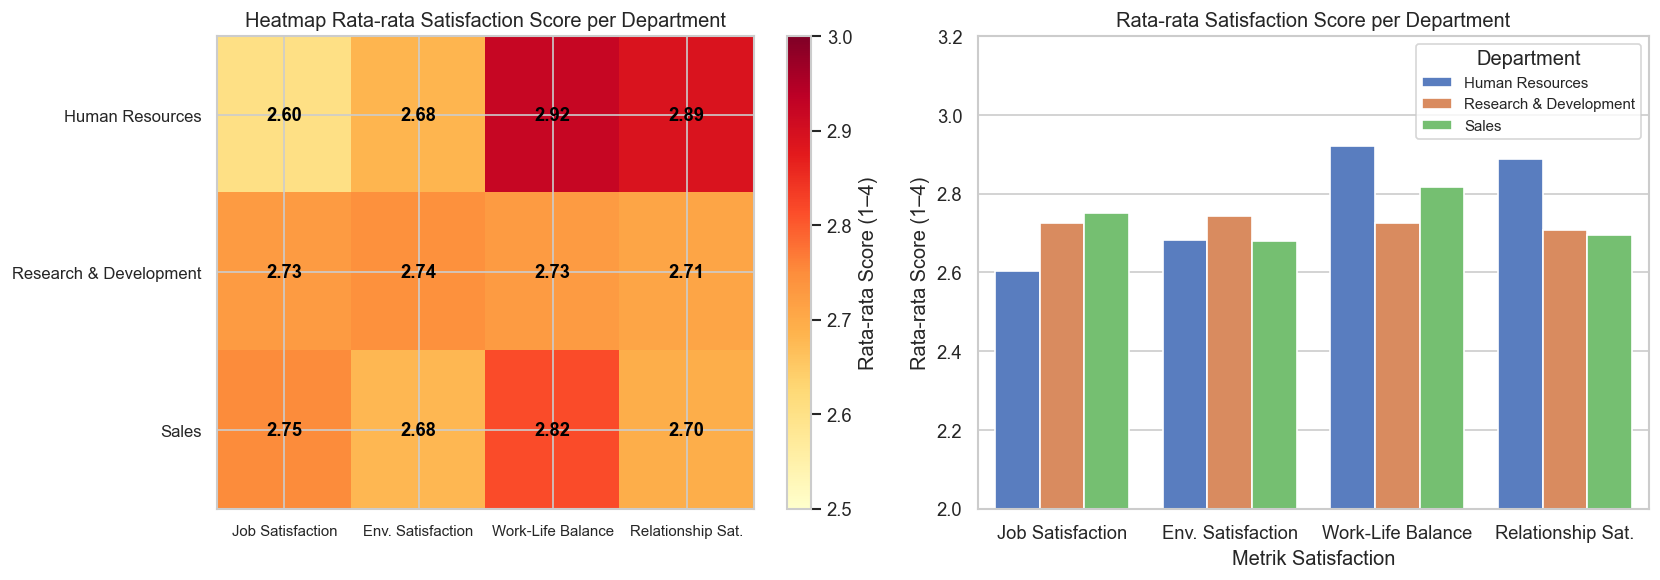

In [75]:
# No. 10 — Kerjakan di sini
sat_cols = ['JobSatisfaction', 'EnvironmentSatisfaction', 'WorkLifeBalance', 'RelationshipSatisfaction']
sat_labels = ['Job Satisfaction', 'Env. Satisfaction', 'Work-Life Balance', 'Relationship Sat.']

dept_sat = df.groupby('Department')[sat_cols].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left Plot: Heatmap
im = axes[0].imshow(dept_sat.values, cmap='YlOrRd', aspect='auto', vmin=2.5, vmax=3.0)
axes[0].set_xticks(range(len(sat_labels)))
axes[0].set_xticklabels(sat_labels, fontsize=9)
axes[0].set_yticks(range(len(dept_sat.index)))
axes[0].set_yticklabels(dept_sat.index, fontsize=10)
axes[0].set_title('Heatmap Rata-rata Satisfaction Score per Department')
plt.colorbar(im, ax=axes[0], label='Rata-rata Score (1–4)')
for i in range(len(dept_sat.index)):
    for j in range(len(sat_cols)):
        axes[0].text(j, i, f'{dept_sat.values[i, j]:.2f}', ha='center', va='center',
                     fontsize=11, fontweight='bold', color='black')

# Right Plot: Grouped bar
dept_sat_melt = dept_sat.reset_index().melt(id_vars='Department', var_name='Metric', value_name='Score')
dept_sat_melt['Metric'] = dept_sat_melt['Metric'].map(dict(zip(sat_cols, sat_labels)))
sns.barplot(data=dept_sat_melt, x='Metric', y='Score', hue='Department',
            palette='muted', ax=axes[1])
axes[1].set_title('Rata-rata Satisfaction Score per Department')
axes[1].set_xlabel('Metrik Satisfaction')
axes[1].set_ylabel('Rata-rata Score (1–4)')
axes[1].set_ylim(2.0, 3.2)
axes[1].legend(title='Department', fontsize=9)

plt.tight_layout()
plt.show()

#### 💡 Insight No. 10

| | |
|---|---|
| 📊 **Observasi** | *All three departments score between 2.6–2.8 on every metric out of 4, meaning satisfaction is universally mediocre across the board. R&D has the lowest Work-Life Balance at just 2.73, while HR has the lowest Job Satisfaction (2.60) and Environment Satisfaction (2.68). Sales scores highest on Job Satisfaction but lowest on Environment Satisfaction.* |
| 🔍 **Interpretasi** | *No single department is thriving with all scores hovering around Medium (2) compared to 3 which points to a company-wide culture issue. This is also surprising since HR, despite having more than favorable ratio to support all departments still has lackluster scores which may impact their support to other employees.* |
| 📌 **Rekomendasi** | *Rather than focusing on just one department, we need to address satisfaction at the company level. This may include better work-life policies, management, and work culture in general.* |


---
### No. 11 — Bagaimana komposisi status lembur (OverTime) di setiap Department?

**Business Question:**  
*Bagaimana komposisi status lembur (OverTime) di setiap Department?*
 
**Kolom:** `Department`, `OverTime`


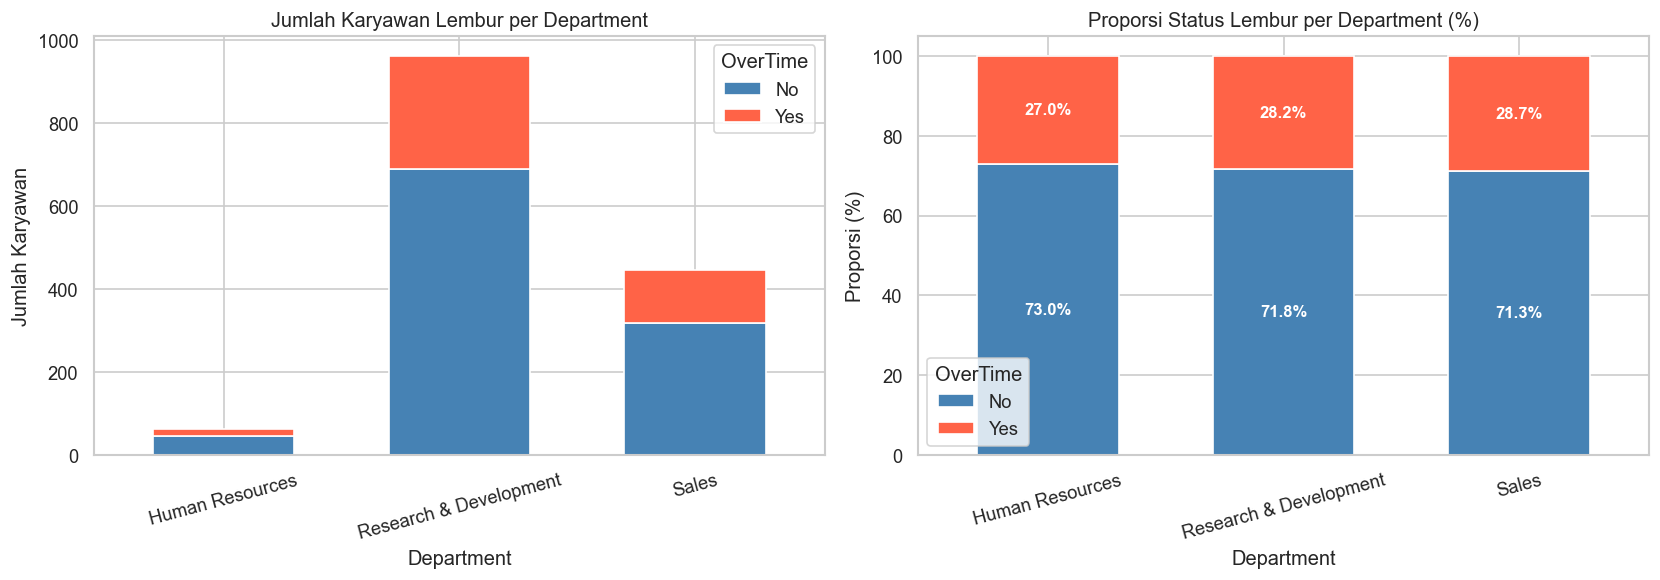

In [85]:
# No. 11 — Kerjakan di sini
ot_dept = pd.crosstab(df['Department'], df['OverTime'])
ot_dept_pct = ot_dept.div(ot_dept.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot kiri: Stacked bar (absolut)
ot_dept.plot(kind='bar', stacked=True, ax=axes[0],
             color=['steelblue', 'tomato'], edgecolor='white', width=0.6)
axes[0].set_title('Jumlah Karyawan Lembur per Department')
axes[0].set_xlabel('Department')
axes[0].set_ylabel('Jumlah Karyawan')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15)
axes[0].legend(title='OverTime', labels=['No', 'Yes'])

# Plot kanan: Stacked bar (proporsi)
ot_dept_pct.plot(kind='bar', stacked=True, ax=axes[1],
                 color=['steelblue', 'tomato'], edgecolor='white', width=0.6)
for i, (_, row) in enumerate(ot_dept_pct.iterrows()):
    axes[1].text(i, row['No']/2, f"{row['No']:.1f}%", ha='center', va='center',
                 color='white', fontweight='bold', fontsize=10)
    axes[1].text(i, row['No'] + row['Yes']/2, f"{row['Yes']:.1f}%", ha='center', va='center',
                 color='white', fontweight='bold', fontsize=10)

axes[1].set_title('Proporsi Status Lembur per Department (%)')
axes[1].set_xlabel('Department')
axes[1].set_ylabel('Proporsi (%)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15)
axes[1].legend(title='OverTime', labels=['No', 'Yes'])

plt.tight_layout()
plt.show()

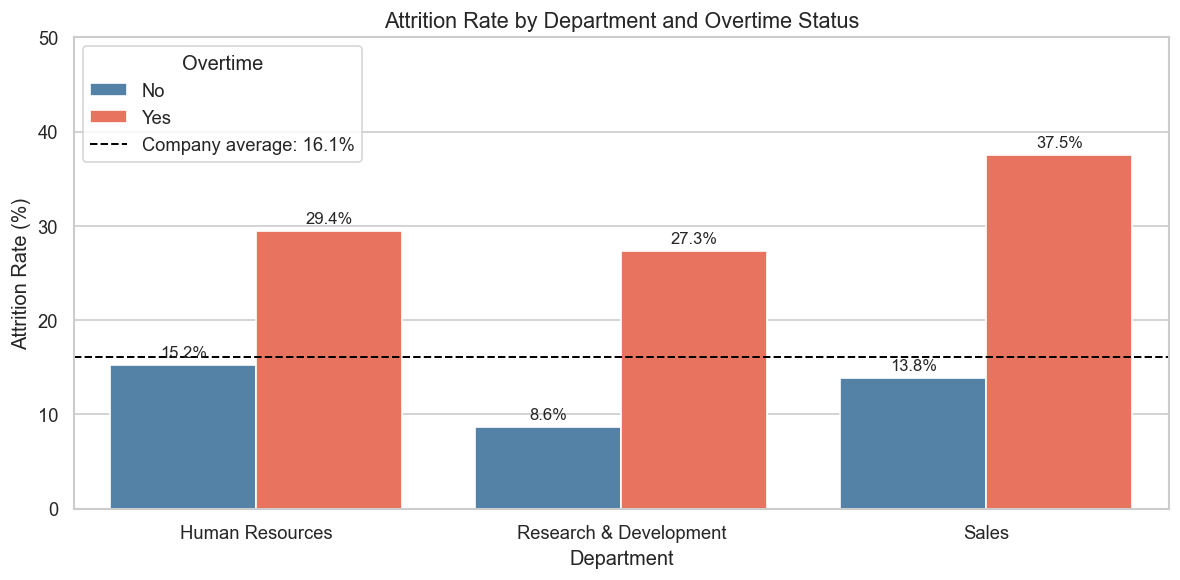

            Department OverTime  Attrition Rate (%)
       Human Resources       No                15.2
       Human Resources      Yes                29.4
Research & Development       No                 8.6
Research & Development      Yes                27.3
                 Sales       No                13.8
                 Sales      Yes                37.5


In [86]:
# Attrition rate by Department × Overtime status
overtime_attrition = (
    df.groupby(['Department', 'OverTime'])['Attrition_bin']
    .mean()
    .mul(100)
    .round(1)
    .reset_index()
    .rename(columns={'Attrition_bin': 'Attrition Rate (%)'})
)

fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=overtime_attrition,
    x='Department',
    y='Attrition Rate (%)',
    hue='OverTime',
    palette={'No': 'steelblue', 'Yes': 'tomato'},
    ax=ax
)

# Annotate each bar with its percentage
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=10, padding=3)

# Company average reference line
avg_rate = df['Attrition_bin'].mean() * 100
ax.axhline(avg_rate, color='black', linestyle='--', linewidth=1.2,
           label=f'Company average: {avg_rate:.1f}%')

ax.set_title('Attrition Rate by Department and Overtime Status', fontsize=13)
ax.set_xlabel('Department')
ax.set_ylabel('Attrition Rate (%)')
ax.set_ylim(0, 50)
ax.legend(title='Overtime')

plt.tight_layout()
plt.show()

# Print the numbers as a table for reference
print(overtime_attrition.to_string(index=False))

#### 💡 Insight No. 11

| | |
|---|---|
| 📊 **Observasi** | *Overtime rates are mostly similiar across all three departments HR (27%), R&D(28.2), Sales(28.7%) which has more than a quarter of their employees working overtime. Moreover from the additional data, overtime employees who resigned account for 37.5% in sales, 27.3% in R&D, and 29.4% in HR.* |
| 🔍 **Interpretasi** | *Overtime is mostly spread evenly across all departments, but Sales department has the biggest attrition of employee due to overtime. This can suggest with the amount of high-pressure target set by the company and increased workflow, most employees just ended up resigning in frustration. Moreover the gap between OT vs Non-OT attrition is supported by 2-3x gap which suggests that overwork is a major factor of resignation.* |
| 📌 **Rekomendasi** | *Reduce the amount of overtime across all departments, this can be done by hiring more employees or compensating them appropriately.* |


---
### No. 12 — Apakah karyawan dengan jarak rumah lebih jauh cenderung lebih banyak resign?

**Business Question:**  
*Apakah karyawan dengan jarak rumah lebih jauh cenderung lebih banyak resign?*

**Kolom:** `DistanceFromHome`, `Attrition_bin`


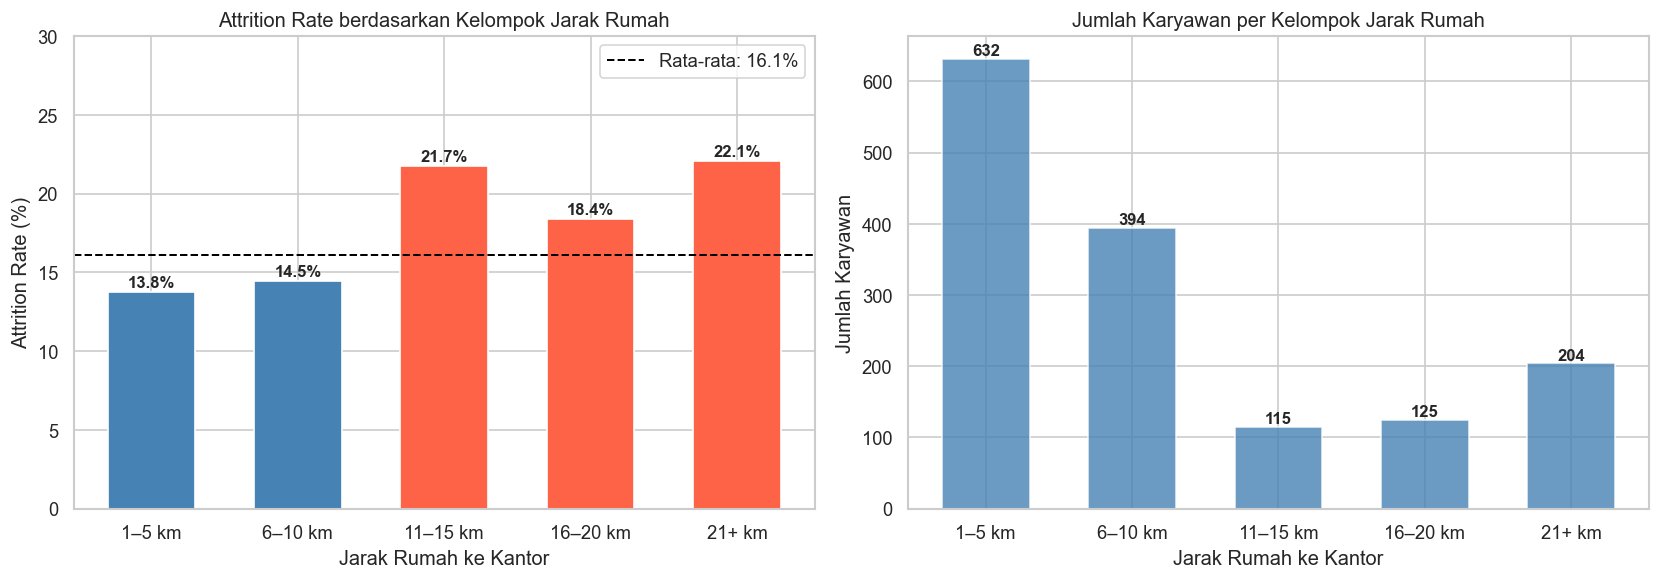

In [ ]:
# No. 12 — Kerjakan di sini
bins = [0, 5, 10, 15, 20, 30]
labels = ['1–5 km', '6–10 km', '11–15 km', '16–20 km', '21+ km']
df['DistBin'] = pd.cut(df['DistanceFromHome'], bins=bins, labels=labels)

dist_attrition = df.groupby('DistBin', observed=True)['Attrition_bin'].agg(['mean', 'count']).reset_index()
dist_attrition['attrition_pct'] = dist_attrition['mean'] * 100

colors = ['tomato' if v > 18 else 'steelblue' for v in dist_attrition['attrition_pct']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left Plot: Bar attrition rate per distance group
bars = axes[0].bar(dist_attrition['DistBin'].astype(str), dist_attrition['attrition_pct'],
                   color=colors, edgecolor='white', width=0.6)
for bar, val in zip(bars, dist_attrition['attrition_pct']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=10)
axes[0].axhline(df['Attrition_bin'].mean()*100, color='black', linestyle='--',
                linewidth=1.2, label=f"Rata-rata: {df['Attrition_bin'].mean()*100:.1f}%")
axes[0].set_title('Attrition Rate berdasarkan Kelompok Jarak Rumah')
axes[0].set_xlabel('Jarak Rumah ke Kantor')
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].legend()
axes[0].set_ylim(0, 30)

# Right Plot: Number of employees per bin
axes[1].bar(dist_attrition['DistBin'].astype(str), dist_attrition['count'],
            color='steelblue', edgecolor='white', width=0.6, alpha=0.8)
for bar, val in zip(axes[1].patches, dist_attrition['count']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(val), ha='center', fontweight='bold', fontsize=10)
axes[1].set_title('Jumlah Karyawan per Kelompok Jarak Rumah')
axes[1].set_xlabel('Jarak Rumah ke Kantor')
axes[1].set_ylabel('Jumlah Karyawan')

plt.tight_layout()
plt.show()

#### 💡 Insight No. 12

| | |
|---|---|
| 📊 **Observasi** | *Employees living between 1-5km have the lowest attrition rate compared to a massive jump at around 11-15km (Indicated by the red bars). The attrition rate stays consistent across the board with the furthest ones hovering around 20% attrition on average. * |
| 🔍 **Interpretasi** | *Long commutes are also a factor for employees. Employees who are already unhappy are likely to quit if they're spending a significant amount of time in a day just commuting to work and vice-versa. This can suggest they are more at risk to quit or to find other job opportunites closer to their residence.* |
| 📌 **Rekomendasi** | *Offering a hybrid-remote work for employees on a rotating basis or for those who like beyond 10km. Even a couple of remote days in a week reduces fatigue significantly. Furthermore, more critical roles can be compensated with transport allowances or increased pay to make up for their commute.* |


---
## ⚠️ Advanced Questions (No. 13–15)

> 🔴 Kerjakan setelah No. 1–12 selesai.  
> Penggunaan `subplots` **diizinkan** pada nomor-nomor berikut.


---
### No. 13 — Distribusi Gaji dan Lama Bekerja: Resign vs Tidak
> 🔴 **Advanced**

**Business Question:**  
*Bagaimana distribusi gaji dan lama bekerja berbeda antara karyawan yang resign vs tidak?*

**Kolom:** `MonthlyIncome`, `YearsAtCompany`, `Attrition`

**Petunjuk struktur:**
- Gunakan `subplots(1, 2)` dengan `figsize=(14, 5)`
- Plot kiri: Histogram `MonthlyIncome` dengan overlay Attrition Yes/No
- Plot kanan: Boxplot `YearsAtCompany` per Attrition group
- Gunakan warna konsisten: `steelblue` untuk No, `tomato` untuk Yes di kedua chart


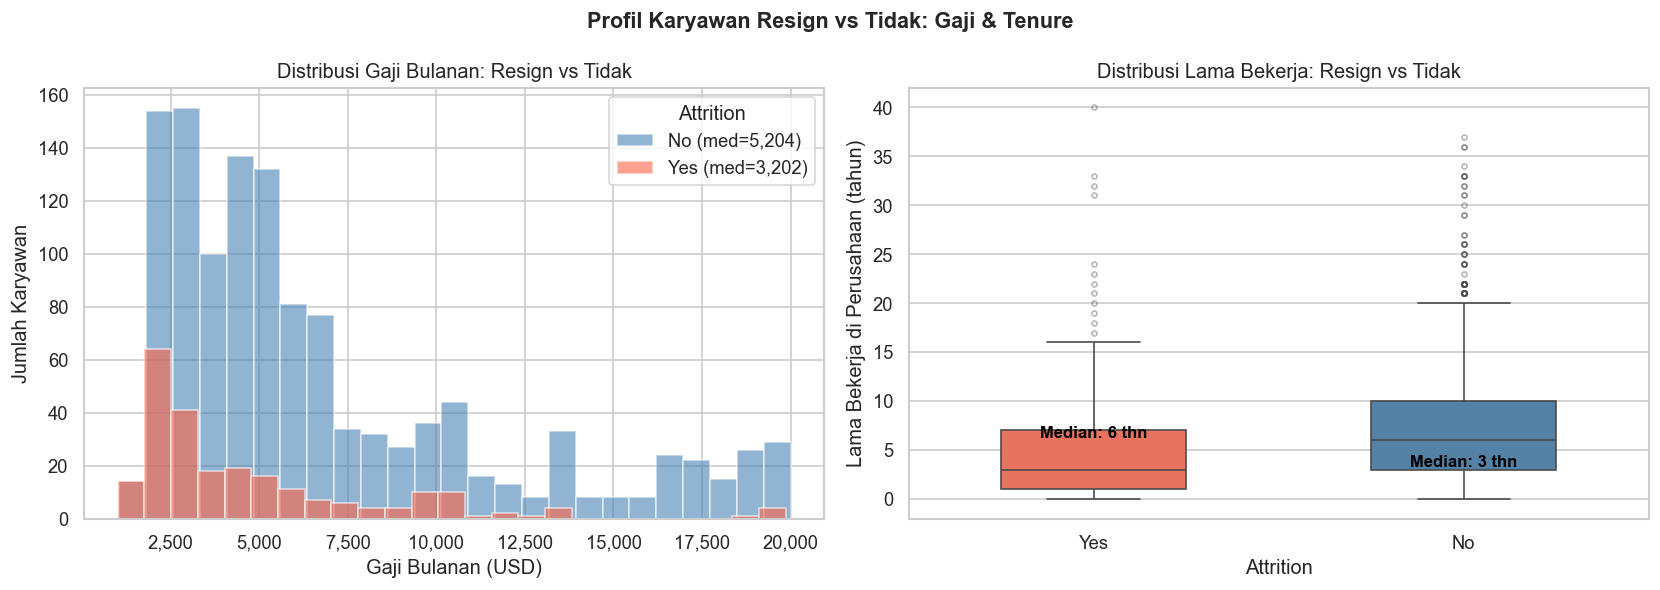

In [80]:
# No. 13 — Kerjakan di sini
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left Plot: Histogram MonthlyIncome
for group, color in [('No', 'steelblue'), ('Yes', 'tomato')]:
    subset = df[df['Attrition'] == group]['MonthlyIncome']
    axes[0].hist(subset, bins=25, alpha=0.6, color=color, edgecolor='white',
                 label=f'{group} (med={int(subset.median()):,})')
axes[0].set_title('Distribusi Gaji Bulanan: Resign vs Tidak')
axes[0].set_xlabel('Gaji Bulanan (USD)')
axes[0].set_ylabel('Jumlah Karyawan')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].legend(title='Attrition')

# Right Plot: Boxplot YearsAtCompany
sns.boxplot(data=df, x='Attrition', y='YearsAtCompany',
            palette={'No': 'steelblue', 'Yes': 'tomato'},
            width=0.5,
            flierprops=dict(marker='o', markersize=3, alpha=0.4),
            ax=axes[1])

# Annotate median
for i, group in enumerate(['No', 'Yes']):
    med = df[df['Attrition']==group]['YearsAtCompany'].median()
    axes[1].text(i, med + 0.3, f'Median: {med:.0f} thn',
                 ha='center', fontsize=10, color='black', fontweight='bold')

axes[1].set_title('Distribusi Lama Bekerja: Resign vs Tidak')
axes[1].set_xlabel('Attrition')
axes[1].set_ylabel('Lama Bekerja di Perusahaan (tahun)')

plt.suptitle('Profil Karyawan Resign vs Tidak: Gaji & Tenure', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### 💡 Insight No. 13

| | |
|---|---|
| 📊 **Observasi** | *(Apa yang terlihat dari chart? Tuliskan fakta, angka, atau pola spesifik)* |
| 🔍 **Interpretasi** | *(Apa makna bisnis dari temuan tersebut?)* |
| 📌 **Rekomendasi** | *(Action apa yang dapat diambil oleh HR/manajemen?)* |


---
### No. 14 — Komposisi MaritalStatus dan Attrition Rate per Job Role

**Business Question:**  
*Bagaimana komposisi MaritalStatus di setiap JobRole, dan JobRole mana yang memiliki attrition rate tertinggi?*
 
**Kolom:** `JobRole`, `MaritalStatus`, `Attrition_bin`

**Petunjuk struktur:**
- Gunakan `subplots(1, 2)` dengan `figsize=(16, 6)`
- Plot kiri: Normalized stacked bar (100%) komposisi `MaritalStatus` per `JobRole`
  - Buat pivot table → normalisasi dengan `.div()` → `.plot(kind='barh', stacked=True)`
- Plot kanan: Horizontal bar chart attrition rate per `JobRole`
- Urutkan `JobRole` berdasarkan attrition rate tertinggi, gunakan urutan yang sama di kedua chart


In [69]:
# No. 14 — Kerjakan di sini


#### 💡 Insight No. 14

| | |
|---|---|
| 📊 **Observasi** | *(Apa yang terlihat dari chart? Tuliskan fakta, angka, atau pola spesifik)* |
| 🔍 **Interpretasi** | *(Apa makna bisnis dari temuan tersebut?)* |
| 📌 **Rekomendasi** | *(Action apa yang dapat diambil oleh HR/manajemen?)* |


---
### No. 15 — Faktor Satisfaction: Karyawan Resign vs Tidak

**Business Question:**  
*Faktor satisfaction mana (Job, Environment, WorkLifeBalance, Relationship) yang paling membedakan karyawan yang resign vs tidak?*

**Kolom:** `JobSatisfaction`, `EnvironmentSatisfaction`, `WorkLifeBalance`, `RelationshipSatisfaction`, `Attrition`

**Petunjuk struktur:**
- Hitung rata-rata keempat kolom satisfaction per Attrition group menggunakan `groupby`
- Gunakan `subplots(1, 2)` dengan `figsize=(14, 5)`
- Plot kiri: Heatmap 2×4 (baris: Yes/No, kolom: 4 metrik) dengan `annot=True`, `cmap='YlOrRd'`
- Plot kanan: Bar chart berdampingan yang menampilkan rata-rata per metrik per Attrition group
- Ini adalah **summary question** — jawab faktor mana yang paling membedakan kedua kelompok


In [70]:
# No. 15 — Kerjakan di sini


#### 💡 Insight No. 15

| | |
|---|---|
| 📊 **Observasi** | *(Apa yang terlihat dari chart? Tuliskan fakta, angka, atau pola spesifik)* |
| 🔍 **Interpretasi** | *(Apa makna bisnis dari temuan tersebut?)* |
| 📌 **Rekomendasi** | *(Action apa yang dapat diambil oleh HR/manajemen?)* |
